This notebook is design to test the Bingham filter. Developed out of the Kurs (et. al, 2014) testing paradigm.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

sys.path.insert(0, os.path.abspath("../../../.."))
from spatial_nav.plane_estimation import init_from_normal_guess, run_bingham_filter, plane_axes, compute_F


Use parameters akin to those of the paper, see section 7.1

In [2]:
N_TRUE  = np.array([0., 0., 1.]) #True plane normal, points straight up
initial = init_from_normal_guess([1., 0., 0.], z1=-0.5, z2=-0.5) #inital system prior, week

KAPPA       = 3   # measurement trust — higher = less noise
N_STEPS     = 60
NOISE_STD   = 0.3   # standard deviation noice before projection to S²

In [3]:
def noisy_in_plane_displacement(n_true, noise_std, rng):
    """
    Sample a random unit vector in the plane defined by n_true,
    then add noise and renormalise to S².
    Return one simulated animal displacement
    """
    # Build two orthogonal axes in the plane
    e1, e2, _ = plane_axes(n_true)
    
    # Random in-plane direction
    angle = rng.uniform(0, 2*np.pi)
    v     = np.cos(angle) * e1 + np.sin(angle) * e2
    
    # Add noise and project back to S²
    v += rng.standard_normal(3) * noise_std
    return v / np.linalg.norm(v) #Projects back onto S² by normalising. 



In [4]:
def angular_error_s2(est_mode, n_true):
    """
    Geodesic error on S² , with the anisotropy of the distribution
    Returns degrees.
    """
    dot = np.clip(abs(np.dot(est_mode, n_true)), 0., 1.)
    return np.rad2deg(np.arccos(dot))


Run the simulations with 100 monte carlo runs.

In [5]:
N_RUNS   = 100
all_errors = np.zeros((N_RUNS, N_STEPS))

for run in range(N_RUNS):
    rng          = np.random.default_rng(run)   # different seed each run
    initial      = init_from_normal_guess([1., 0., 0.], z1=-0.5, z2=-0.5)
    measurements = [noisy_in_plane_displacement(N_TRUE, 0.15, rng)
                    for _ in range(N_STEPS)]
    estimates    = run_bingham_filter(initial, measurements, kappa=10.0, alpha=0.999)
    all_errors[run, :] = [angular_error_s2(e.mode, N_TRUE) for e in estimates]

mean_error = all_errors.mean(axis=0) 
rmse_per_run = np.sqrt((all_errors**2).mean(axis=1)) 

Plot the angular error and the filter concentration 

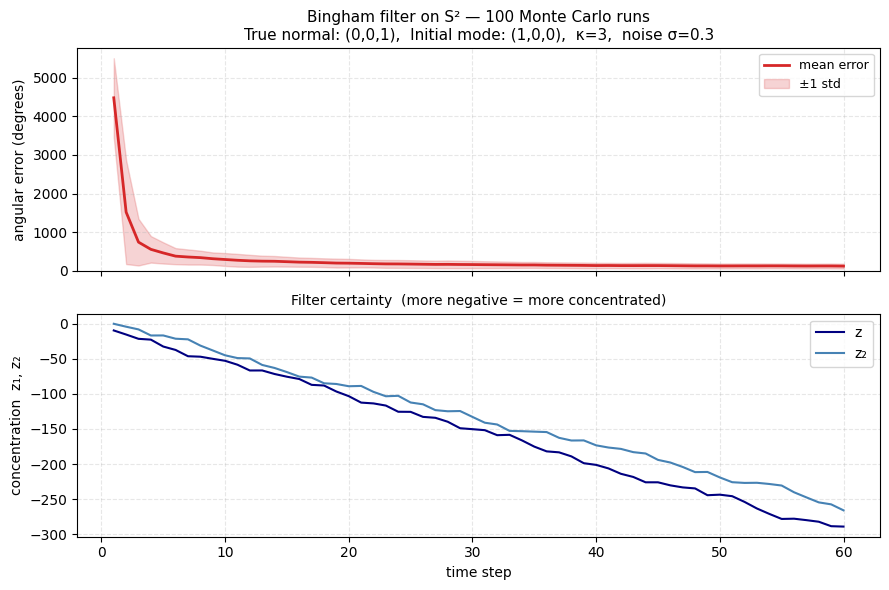

In [6]:
steps = np.arange(1, N_STEPS + 1)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
fig.subplots_adjust(hspace=0.08)

BINGHAM_COL = '#d62728'

mean_error = np.rad2deg(all_errors.mean(axis=0))
std_error  = np.rad2deg(all_errors.std(axis=0))

ax = axes[0]
ax.plot(steps, mean_error, color=BINGHAM_COL, lw=2, label='mean error')
ax.fill_between(steps,
                mean_error - std_error,
                mean_error + std_error,
                color=BINGHAM_COL, alpha=0.2, label='±1 std')
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_ylabel('angular error (degrees)', fontsize=10)
ax.set_title(
    f'Bingham filter on S² — {N_RUNS} Monte Carlo runs\n'
    f'True normal: (0,0,1),  Initial mode: (1,0,0),  '
    f'κ={KAPPA},  noise σ={NOISE_STD}',
    fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, ls='--')
ax.set_ylim(bottom=0)

z1s = [e.z1 for e in estimates]
z2s = [e.z2 for e in estimates]

ax2 = axes[1]
ax2.plot(steps, z1s, color='navy',      lw=1.5, label='z')
ax2.plot(steps, z2s, color='steelblue', lw=1.5, label='z₂')
ax2.set_ylabel('concentration  z₁, z₂', fontsize=10)
ax2.set_xlabel('time step', fontsize=10)
ax2.set_title('Filter certainty  (more negative = more concentrated)',
              fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, ls='--')

plt.tight_layout()
plt.savefig('s2_filter_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
def bingham_pdf_on_sphere(estimate, F, n_points=100):
    theta = np.linspace(0, np.pi,    n_points) #polar angles
    phi   = np.linspace(0, 2*np.pi, n_points) #azimuthal angles
    T, P  = np.meshgrid(theta, phi) #tile the sphere manifold with all possible pairings

    #spherical coordinates to cartesian conversion
    X = np.sin(T) * np.cos(P)
    Y = np.sin(T) * np.sin(P)
    Z = np.cos(T)

    A    = estimate.M @ estimate.Z @ estimate.M.T
    pts  = np.stack([X, Y, Z], axis=-1)
    vals = np.einsum('ijk,kl,ijl->ij', pts, A, pts)
    PDF  = np.exp(vals) / F

    return X, Y, Z, PDF

In [8]:
SNAPSHOTS = [1, 9, 30, 59]
rng_plot  = np.random.default_rng(42)
initial   = init_from_normal_guess([1., 0., 0.], z1=-0.5, z2=-0.5)
meas_plot = [noisy_in_plane_displacement(N_TRUE, 0.15, rng_plot)
             for _ in range(60)]
ests_plot = run_bingham_filter(initial, meas_plot, kappa=10.0, alpha=0.999)

# Precompute F for each snapshot
F_lookup = {}
F_lookup[0] = compute_F(initial.z1, initial.z2)
F_lookup = {}
for t in SNAPSHOTS:
    F_lookup[t] = compute_F(ests_plot[t - 1].z1, 
                            ests_plot[t - 1].z2)

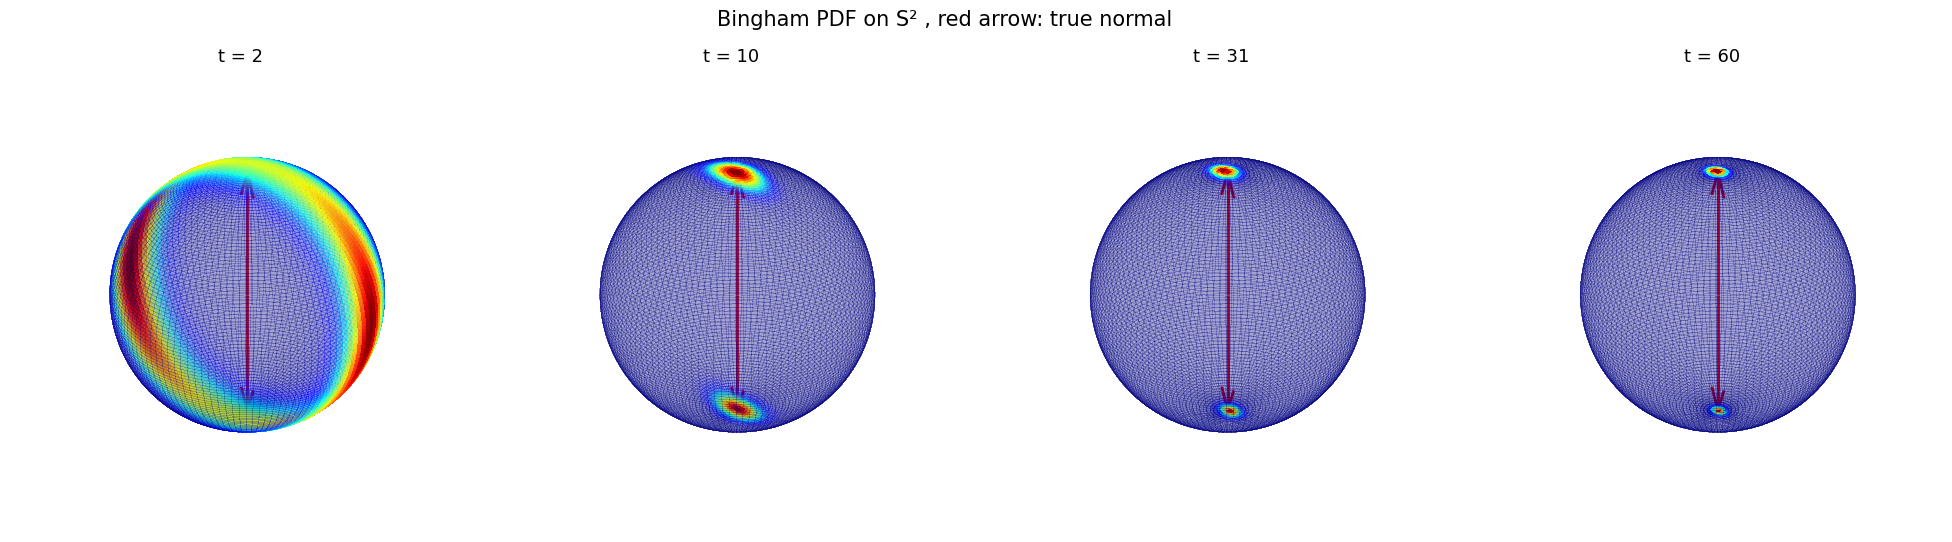

In [9]:
fig = plt.figure(figsize=(25, 6))
fig.subplots_adjust(wspace=0.05)

for i, t in enumerate(SNAPSHOTS):
    ax = fig.add_subplot(1, len(SNAPSHOTS), i+1, projection='3d')
    
    est = ests_plot[t - 1]

    X, Y, Z, PDF = bingham_pdf_on_sphere(est, F_lookup[t], n_points=120)

    norm     = Normalize(vmin=PDF.min(), vmax=PDF.max())
    PDF_norm = norm(PDF)
    colors   = cm.jet(PDF_norm)
    
    # Minimum alpha of 0.2 so the sphere shape is always visible,
    colors[..., 3] = 0.2 + 0.8 * PDF_norm

    ax.plot_surface(X, Y, Z, facecolors=colors,
                    rstride=1, cstride=1,
                    linewidth=0, antialiased=False, shade=False)

    # True normal marked as an arrow , both antipodal directions to show the plane
    ax.quiver(0, 0, 0,
          N_TRUE[0], N_TRUE[1], N_TRUE[2],
          color='red', linewidth=2, arrow_length_ratio=0.2)
    ax.quiver(0, 0, 0,
          -N_TRUE[0], -N_TRUE[1], -N_TRUE[2],
          color='red', linewidth=2, arrow_length_ratio=0.2)


    ax.set_title(f't = {t+1}', fontsize=13)
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_box_aspect([1, 1, 1])
    ax.axis('off')

fig.suptitle('Bingham PDF on S² , red arrow: true normal',
             fontsize=15)
plt.savefig('bingham_sphere.png', dpi=150, bbox_inches='tight')
plt.show()